# M2A9 - Redes Neurais Convolucionais (CNNs)

> **Resumo:** As CNNs são o coração da visão computacional moderna! Diferente do MLP que trata pixels como vetor, as CNNs entendem a **estrutura espacial** das imagens usando convoluções (que já vimos no Módulo 1!).

> 📝 **Conexão com o Módulo 1:** Lembra dos filtros de convolução (Sobel, Gaussian)? Nas CNNs, os filtros são **aprendidos** automaticamente durante o treino!

**Estrutura do notebook:**

- As 3 camadas de uma CNN
- Prática: convoluções e pooling manuais
- Arquiteturas famosas (LeNet, AlexNet)
- ✅ Atividades Complementares

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

## As 3 Camadas de uma CNN

| Camada | O que faz | Analogia |
|--------|-----------|----------|
| **Convolucional** | Aplica filtros pra detectar padrões (bordas, texturas) | Os "olhos" da rede |
| **Pooling** | Reduz dimensão mantendo informação importante | "Resumo" da imagem |
| **Fully Connected (MLP)** | Classifica usando as features extraídas | O "cérebro" da rede |

## Prática — Convoluções e Pooling na mão

In [2]:
# Carregar uma imagem do MNIST pra brincar
mnist = torchvision.datasets.MNIST(root='/content/data', train=True, download=True,
                                    transform=torchvision.transforms.ToTensor())
img, label = mnist[0]
print(f"Imagem: dígito {label}, shape: {img.shape}")

Imagem: dígito 5, shape: torch.Size([1, 28, 28])


### Aplicando convoluções manualmente

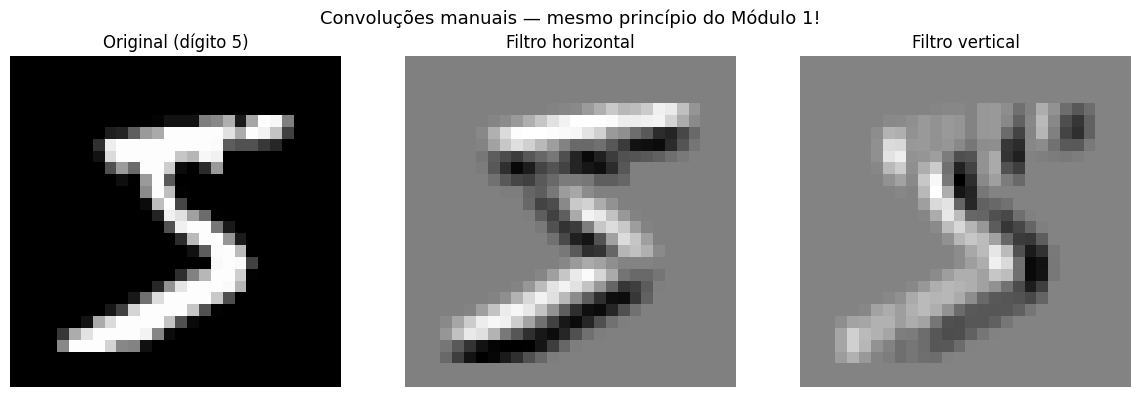

Estatísticas das ativações pós-convolução:
  - Filtro Horizontal: Shape=torch.Size([1, 1, 28, 28]) | Min=-2.98 | Max=2.98 | Média=0.00
  - Filtro Vertical:   Shape=torch.Size([1, 1, 28, 28]) | Min=-2.93 | Max=2.73 | Média=0.00


In [3]:
# Definir filtros manualmente (como no Módulo 1!)
# Filtro de bordas horizontais
filter_horizontal = torch.tensor([[-1., -1., -1.],
                                   [ 0.,  0.,  0.],
                                   [ 1.,  1.,  1.]]).unsqueeze(0).unsqueeze(0)

# Filtro de bordas verticais
filter_vertical = torch.tensor([[-1., 0., 1.],
                                 [-1., 0., 1.],
                                 [-1., 0., 1.]]).unsqueeze(0).unsqueeze(0)

# Aplicar convolução
conv_h = F.conv2d(img.unsqueeze(0), filter_horizontal, padding=1)
conv_v = F.conv2d(img.unsqueeze(0), filter_vertical, padding=1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img.squeeze(), cmap='gray')
axes[0].set_title(f"Original (dígito {label})")
axes[1].imshow(conv_h.squeeze().detach(), cmap='gray')
axes[1].set_title("Filtro horizontal")
axes[2].imshow(conv_v.squeeze().detach(), cmap='gray')
axes[2].set_title("Filtro vertical")
for ax in axes:
    ax.axis("off")
plt.suptitle("Convoluções manuais — mesmo princípio do Módulo 1!", fontsize=13)
plt.tight_layout()
plt.show()

print("Estatísticas das ativações pós-convolução:")
print(f"  - Filtro Horizontal: Shape={conv_h.shape} | Min={conv_h.min().item():.2f} | Max={conv_h.max().item():.2f} | Média={conv_h.mean().item():.2f}")
print(f"  - Filtro Vertical:   Shape={conv_v.shape} | Min={conv_v.min().item():.2f} | Max={conv_v.max().item():.2f} | Média={conv_v.mean().item():.2f}")

> 📝 **Diferença crucial:** No Módulo 1, nós ESCOLHEMOS os filtros (Sobel, Gaussian). Numa CNN, os filtros são APRENDIDOS! A rede descobre sozinha quais filtros são úteis.

### Max Pooling vs Average Pooling

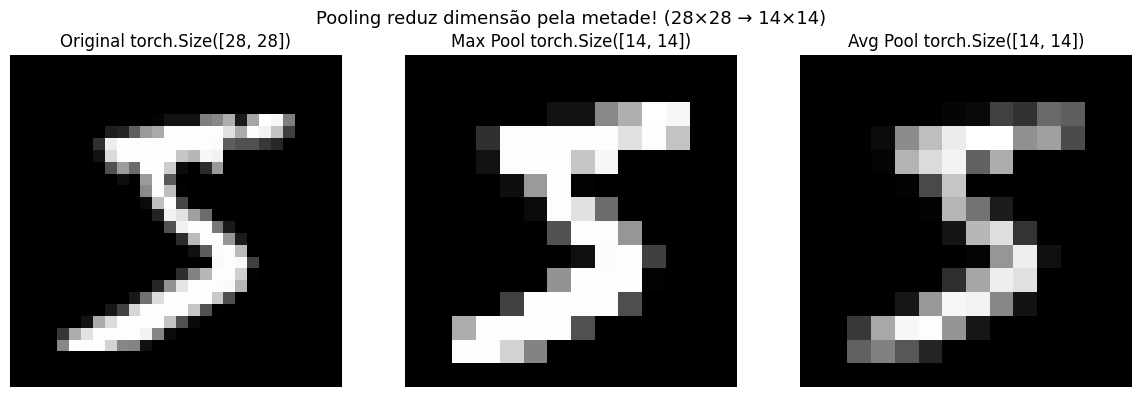

Redução: 784 pixels → 196 pixels = 25% do original
Shapes após Pooling:
  - Original: torch.Size([1, 1, 28, 28])
  - Max Pooling: torch.Size([1, 1, 14, 14])
  - Avg Pooling: torch.Size([1, 1, 14, 14])


In [4]:
# Aplicar pooling
max_pool = F.max_pool2d(img.unsqueeze(0), kernel_size=2)
avg_pool = F.avg_pool2d(img.unsqueeze(0), kernel_size=2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img.squeeze(), cmap='gray')
axes[0].set_title(f"Original {img.shape[-2:]}")
axes[1].imshow(max_pool.squeeze(), cmap='gray')
axes[1].set_title(f"Max Pool {max_pool.shape[-2:]}")
axes[2].imshow(avg_pool.squeeze(), cmap='gray')
axes[2].set_title(f"Avg Pool {avg_pool.shape[-2:]}")
for ax in axes:
    ax.axis("off")
plt.suptitle("Pooling reduz dimensão pela metade! (28×28 → 14×14)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Redução: {28*28} pixels → {14*14} pixels = {14*14*100//(28*28)}% do original")
print(f"Shapes após Pooling:")
print(f"  - Original: {img.unsqueeze(0).shape}")
print(f"  - Max Pooling: {max_pool.shape}")
print(f"  - Avg Pooling: {avg_pool.shape}")

### Empilhando camadas: como a resolução cai

In [5]:
x = img.unsqueeze(0)
shapes = [x.shape[-2:]]

# Simular pipeline CNN: conv → pool → conv → pool → conv → pool
layers = []
for i in range(4):
    x = F.max_pool2d(F.relu(F.conv2d(x, torch.randn(8, x.shape[1], 3, 3), padding=1)), 2)
    shapes.append(x.shape[-2:])

print("Evolução da resolução ao longo da CNN:")
for i, s in enumerate(shapes):
    bar = "█" * (s[0])
    print(f"  Camada {i}: {s[0]:3d}×{s[1]:3d}  {bar}")

Evolução da resolução ao longo da CNN:
  Camada 0:  28× 28  ████████████████████████████
  Camada 1:  14× 14  ██████████████
  Camada 2:   7×  7  ███████
  Camada 3:   3×  3  ███
  Camada 4:   1×  1  █


## Arquiteturas Famosas

### LeNet-5 (1998, Yann LeCun)
- Primeira CNN de sucesso prático
- Usada pra reconhecer dígitos em cheques
- 5 camadas (2 conv + 3 FC)

### AlexNet (2012)
- Venceu o ImageNet com margem ENORME
- Usou ReLU + GPU + Dropout
- Iniciou a era moderna do Deep Learning
- Inspirou VGG, ResNet, etc.

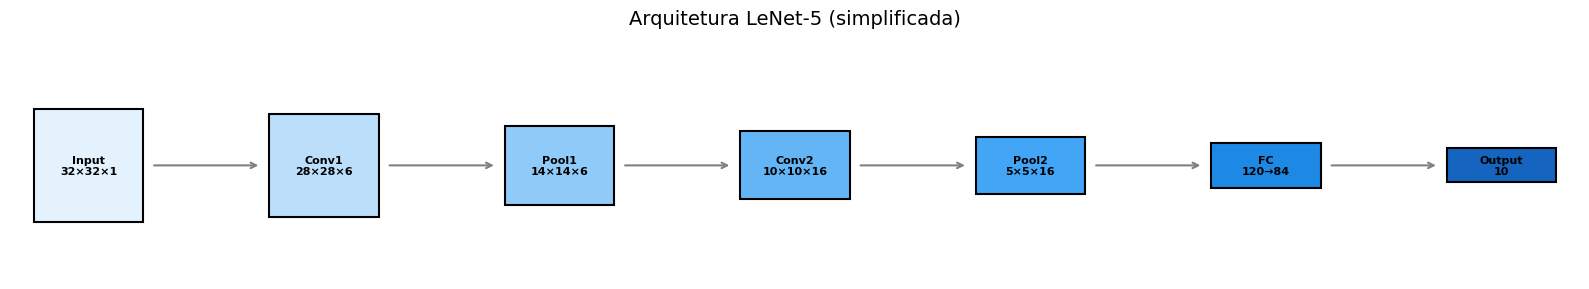

In [6]:
# Visualizar arquitetura da LeNet-5 como diagrama
fig, ax = plt.subplots(figsize=(16, 3))
ax.set_xlim(0, 10); ax.set_ylim(0, 2)
ax.axis("off")

layers_info = [
    (0.5, "Input\n32×32×1", '#E3F2FD', 1.0),
    (2.0, "Conv1\n28×28×6", '#BBDEFB', 0.9),
    (3.5, "Pool1\n14×14×6", '#90CAF9', 0.7),
    (5.0, "Conv2\n10×10×16", '#64B5F6', 0.6),
    (6.5, "Pool2\n5×5×16", '#42A5F5', 0.5),
    (8.0, "FC\n120→84", '#1E88E5', 0.4),
    (9.5, "Output\n10", '#1565C0', 0.3),
]

for x, label, color, h in layers_info:
    rect = plt.Rectangle((x - 0.35, 1 - h/2), 0.7, h, fc=color, ec='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, 1, label, ha='center', va='center', fontsize=8, fontweight='bold')

# Setas
for i in range(len(layers_info) - 1):
    ax.annotate('', xy=(layers_info[i+1][0] - 0.4, 1),
                xytext=(layers_info[i][0] + 0.4, 1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title("Arquitetura LeNet-5 (simplificada)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## ✅ Atividades Complementares

### Visualizar filtros aprendidos de uma CNN real

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 273MB/s] 


Shape dos filtros: torch.Size([64, 3, 3, 3])


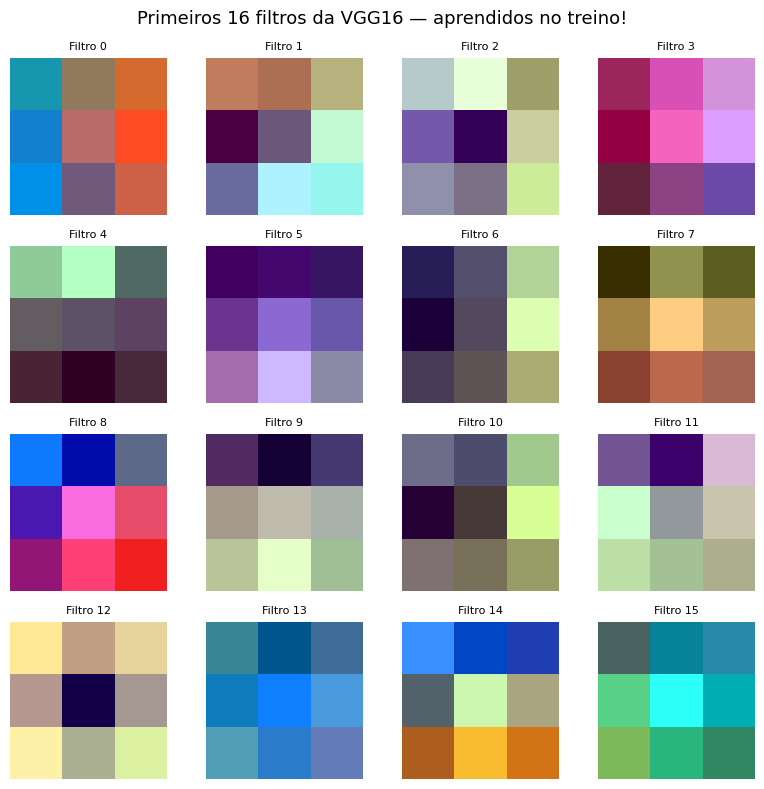

In [7]:
# Carregar uma VGG16 pré-treinada e olhar seus filtros da primeira camada
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
first_conv = vgg.features[0]  # Primeira camada convolucional

# Pegar os filtros (64 filtros de 3×3×3)
filters = first_conv.weight.data.cpu()
print(f"Shape dos filtros: {filters.shape}")  # [64, 3, 3, 3]

# Visualizar os primeiros 16 filtros
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    f = filters[i]
    # Normalizar pra visualização
    f = (f - f.min()) / (f.max() - f.min())
    ax.imshow(f.permute(1, 2, 0))
    ax.set_title(f"Filtro {i}", fontsize=8)
    ax.axis("off")
plt.suptitle("Primeiros 16 filtros da VGG16 — aprendidos no treino!", fontsize=13)
plt.tight_layout()
plt.show()

> 📝 **Observe:** Os filtros da primeira camada se parecem com detectores de bordas e cores — similar ao Sobel que fizemos manualmente! Mas estes foram APRENDIDOS pela rede durante o treinamento na ImageNet.

### Comparar número de parâmetros

In [8]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

models_info = {
    'ResNet-18': torchvision.models.resnet18(),
    'VGG-16': torchvision.models.vgg16(),
}

print("Número de parâmetros:")
for name, model in models_info.items():
    n = count_params(model)
    print(f"  {name:12s}: {n:>15,} ({n/1e6:.1f}M)")

Número de parâmetros:
  ResNet-18   :      11,689,512 (11.7M)
  VGG-16      :     138,357,544 (138.4M)


> 📝 VGG-16 tem ~138M de parâmetros vs ~11M da ResNet-18. A ResNet é mais eficiente graças às conexões residuais (skip connections).